In [11]:
import os
import tarfile
import urllib.request
import ssl
import shutil
import certifi
import numpy as np

In [2]:
# Function to fecth the data
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

In [3]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)

    tgz_path = os.path.join(housing_path, "housing.tgz")

    context = ssl.create_default_context(cafile=certifi.where())

    with urllib.request.urlopen(housing_url, context=context) as response:
        with open(tgz_path, "wb") as file:
            shutil.copyfileobj(response, file)

    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

In [4]:
fetch_housing_data()

In [5]:
# Load the data using pandas
import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [6]:
housing = load_housing_data()

In [7]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


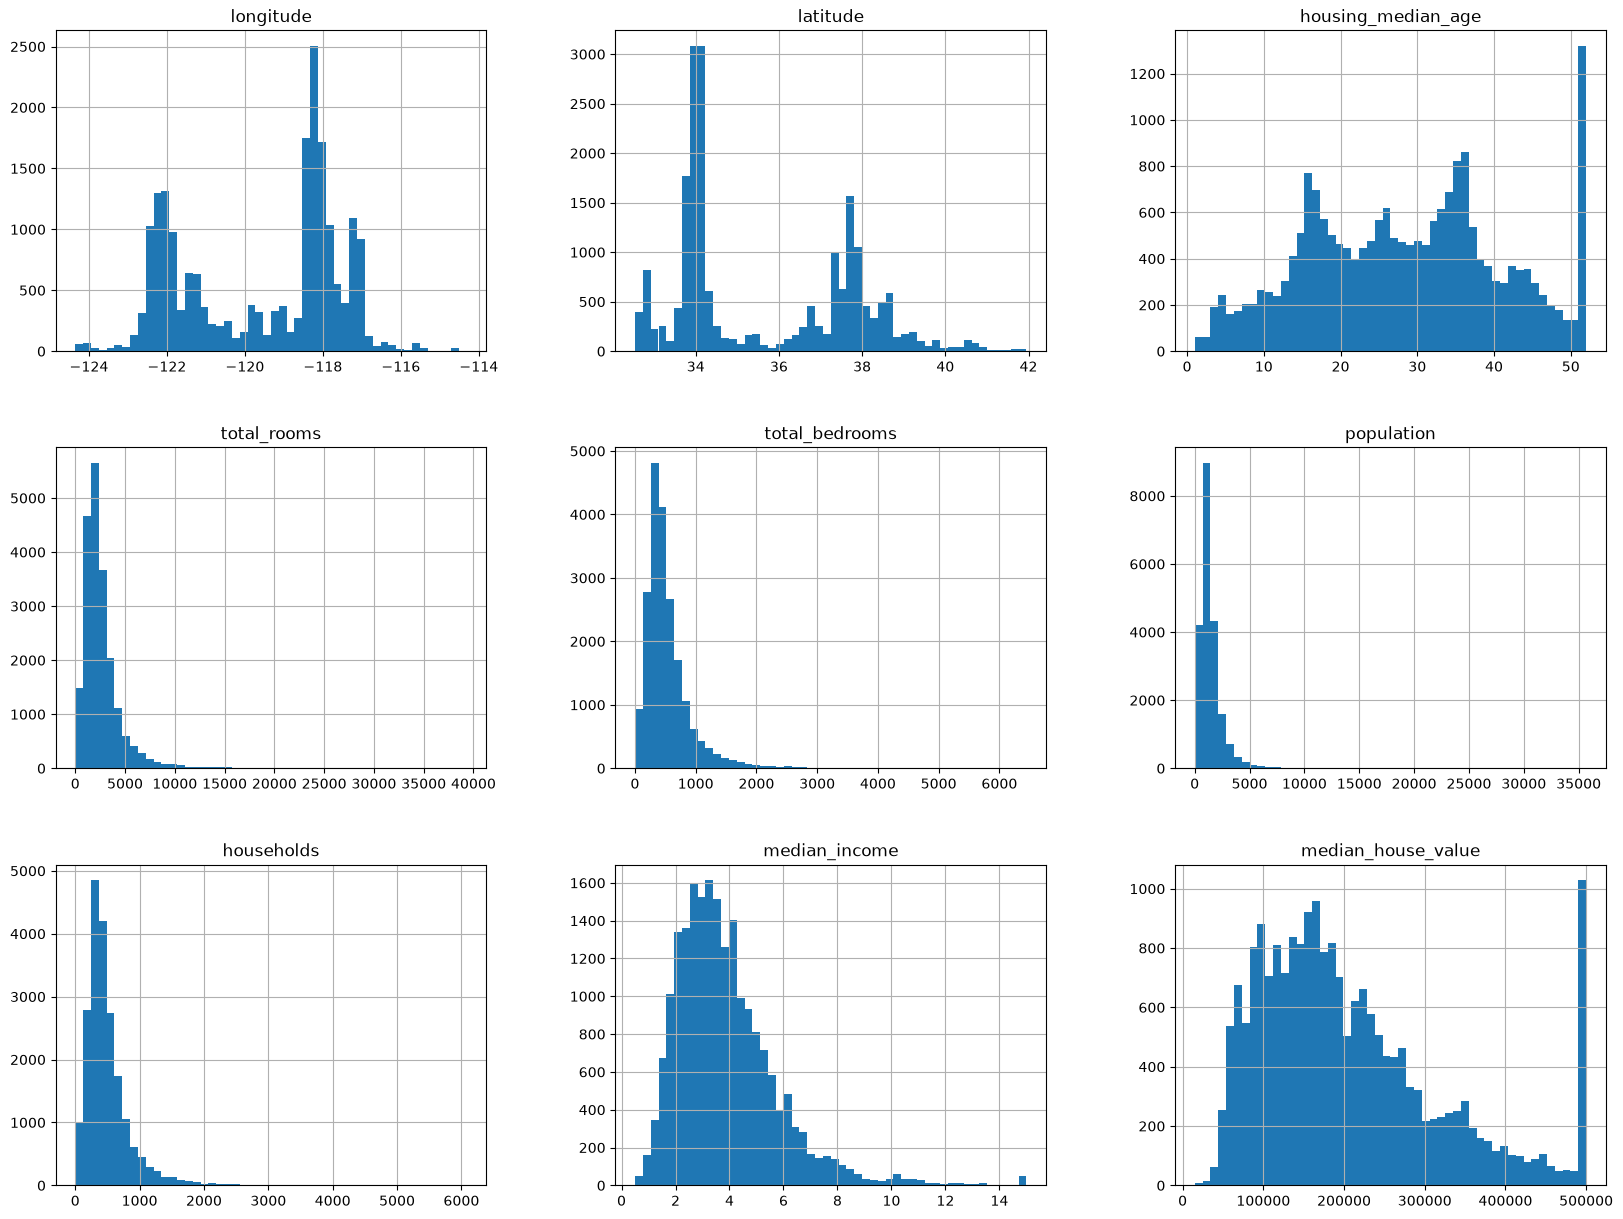

In [9]:
%matplotlib inline 
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [14]:
# Lets defined the categories for the median income
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0.,1.5,3.0,4.5,6.0,np.inf], labels=[1,2,3,4,5]) 

<Axes: >

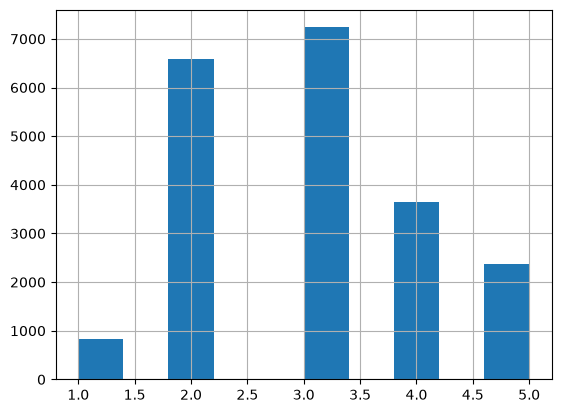

In [15]:
housing['income_cat'].hist()

In [18]:
housing['income_cat'].value_counts(ascending=True)/len(housing)

income_cat
1    0.039826
5    0.114438
4    0.176308
2    0.318847
3    0.350581
Name: count, dtype: float64

In [19]:
# Split the data into test set (RANDOM)
from sklearn.model_selection import train_test_split

In [20]:
random_train_set, random_test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [22]:
random_test_set['income_cat'].value_counts(ascending=True)/len(random_test_set)

income_cat
1    0.040213
5    0.109496
4    0.167393
2    0.324370
3    0.358527
Name: count, dtype: float64

In [23]:
# Split the data into test set (Stratified)
from sklearn.model_selection import StratifiedShuffleSplit

In [27]:
split = StratifiedShuffleSplit(n_splits=1,  test_size=0.2, random_state=42)
split.get_n_splits()

1

In [33]:
for train_index, test_index in split.split(housing, housing['income_cat']):
    strata_train_set = housing.loc[train_index]
    strata_test_set = housing.loc[test_index]

In [34]:
strata_test_set['income_cat'].value_counts(ascending=True)/len(strata_test_set)

income_cat
1    0.039971
5    0.114341
4    0.176357
2    0.318798
3    0.350533
Name: count, dtype: float64

In [40]:
def calculate_proportions(data):
    return data['income_cat'].value_counts()/len(data)

In [46]:
compare_props = pd.DataFrame(
    {
        'Overall': calculate_proportions(housing),
        'Stratified': calculate_proportions(strata_test_set),
        'Random':calculate_proportions(random_test_set)
    }
).sort_index()
compare_props['Strata. % error'] = 100 * compare_props['Stratified']/compare_props['Overall'] - 100
compare_props['Rand. % error'] = 100 * compare_props['Random']/compare_props['Overall'] - 100
compare_props

,Overall,Stratified,Random,Strata. % error,Rand. % error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.364964,0.973236
2,0.318847,0.318798,0.324370,-0.015195,1.732260
3,0.350581,0.350533,0.358527,-0.013820,2.266446
4,0.176308,0.176357,0.167393,0.027480,-5.056334
5,0.114438,0.114341,0.109496,-0.084674,-4.318374


In [49]:
# Remove the income_cat attribute so the data is back to its original state
for set_ in (strata_train_set, strata_test_set):
    set_.drop('income_cat', axis=1, inplace=True)

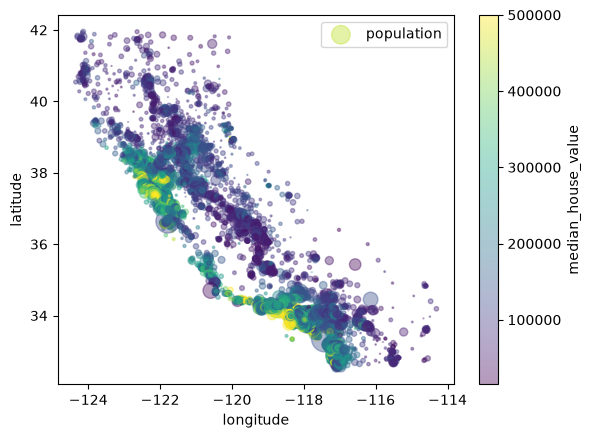

In [70]:
# View the geographical data
housing.plot(
    kind='scatter', 
    x='longitude', 
    y='latitude', 
    alpha=0.4,
    s=housing['population']/100,
    c="median_house_value",
    cmap=plt.get_cmap("viridis"),
    colorbar=True,
    sharex=False,
    label='population'
)
plt.legend()